<a href="https://colab.research.google.com/github/Blazejost/Heart-Failure-Prediction-Project/blob/main/heart_failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Failure Prediction Project

Choroby sercowo-naczyniowe (CVD) są główną przyczyną zgonów na świecie, zabijając około 17,9 miliona osób rocznie, co stanowi 31% wszystkich zgonów na świecie. Cztery na pięć zgonów z powodu CVD to zawały serca i udary mózgu, a jedna trzecia z tych zgonów to przedwczesne zgony osób poniżej 70 roku życia. Niewydolność serca jest częstym zdarzeniem spowodowanym przez CVD, a ten zbiór danych zawiera 11 cech, które można wykorzystać do przewidywania możliwej choroby serca.
Osoby z chorobami sercowo-naczyniowymi lub osoby z wysokim ryzykiem sercowo-naczyniowym (z powodu obecności jednego lub więcej czynników ryzyka, takich jak nadciśnienie, cukrzyca, hiperlipidemia lub już rozpoznana choroba) wymagają wczesnego wykrywania i leczenia, w czym bardzo pomocny może być model uczenia maszynowego.

## Link do zbioru kaggle:


https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction


RestingBP    Ciśnienie spoczynkowe (mmHg)
Cholesterol    Cholesterol całkowity
FastingBS    Cukier na czczo (≥ 120 mg/dl = 1)
MaxHR    Maksymalne tętno
Oldpeak    Obniżenie odcinka ST (wysiłek)
HeartDisease    Choroba serca (0 = nie, 1 = tak)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Read data
df = pd.read_csv("/work/Heart_Failure_Prediction_Project/data/heart.csv")
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [3]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [30]:
cholesterol = df[['Cholesterol']][df[['Cholesterol']] > 0]
print(cholesterol.count())
print("Wartości zerowe kolumny Cholesterol: ", 918-746)

Cholesterol    918
dtype: int64
Wartości zerowe kolumny Cholesterol:  172


172 - 18.7% procent danych. To za dużo żeby odrzucić. Dlatego lepiej wykonać imputację na podstawie mediany, która nie jest podatna na wartości odstające. Cholesterol ma skośny rozkład i średnia byłaby dla niego zła.

In [9]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

median_chol = df['Cholesterol'].median()

df['Cholesterol'].fillna(median_chol, inplace=True)

/tmp/ipykernel_1926/2575183897.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='Cholesterol', bins=30, kde=True, palette='hsv')


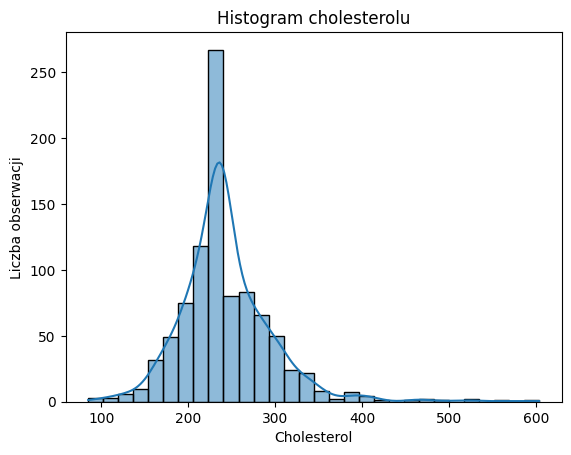

In [96]:
sns.histplot(data=df, x='Cholesterol', bins=30, kde=True, palette='hsv')
plt.xlabel('Cholesterol')
plt.ylabel('Liczba obserwacji')
plt.title('Histogram cholesterolu')
plt.show()

### Histogram cholesterolu jest przekrzywiony w prawo, a najwięcej wartości znajdziemy w przedziale 230-240

In [66]:
print("Pierwszy kwartyl: ", df['Cholesterol'].quantile(0.25))
print("Mediana (drugi kwartyl):",df['Cholesterol'].median())
print("Trzeci kwartyl: ", df['Cholesterol'].quantile(0.75))

Pierwszy kwartyl:  214.0
Mediana (drugi kwartyl): 237.0
Trzeci kwartyl:  267.0


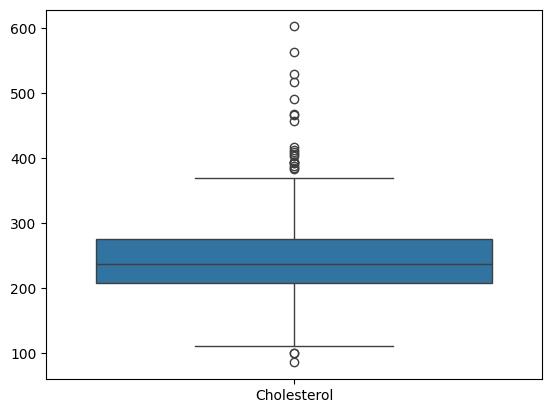

In [13]:
sns.boxplot(data=cholesterol)
plt.show()

Większość danych znajduję się między 214(pierwszy kwartyl) a 267(trzeci kwartyl). Na wykresie wartości odstające są oznaczone kółkami i można zauważyć ich dużą ilość.

In [ ]:
sns.histplot(data=cholesterol, bins=30, kde=True, palette='hsv')
plt.xlabel('Cholesterol')
plt.ylabel('Liczba obserwacji')
plt.title('Histogram cholesterolu')
plt.show()

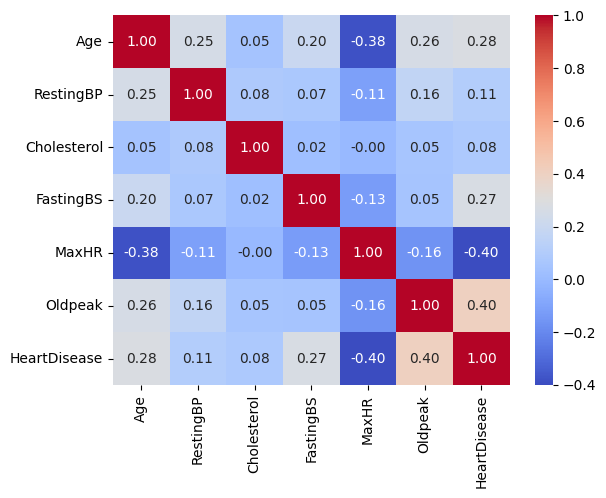

In [14]:
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt='.2f', annot=True)
plt.show()

Między OldPeak a HeartDisease mamy umiarkowaną dodatnią korelacje i również między MaxHR i HeartDisease umiarkowana ujemna. Age i FastingBS ma słabą dodatnią korelacje z HeartDisease.

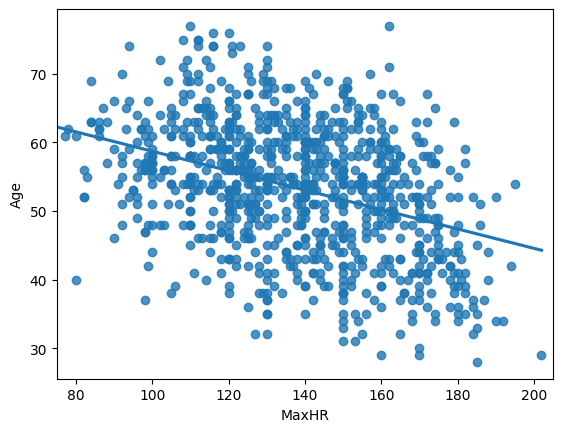

In [87]:
sns.regplot(df, x='MaxHR', y='Age', ci=None)
plt.xlim(75, 205)
plt.show()

Z wykresu możemy zauważyć umiarkowaną ujemną korelację między Age a MaxHR

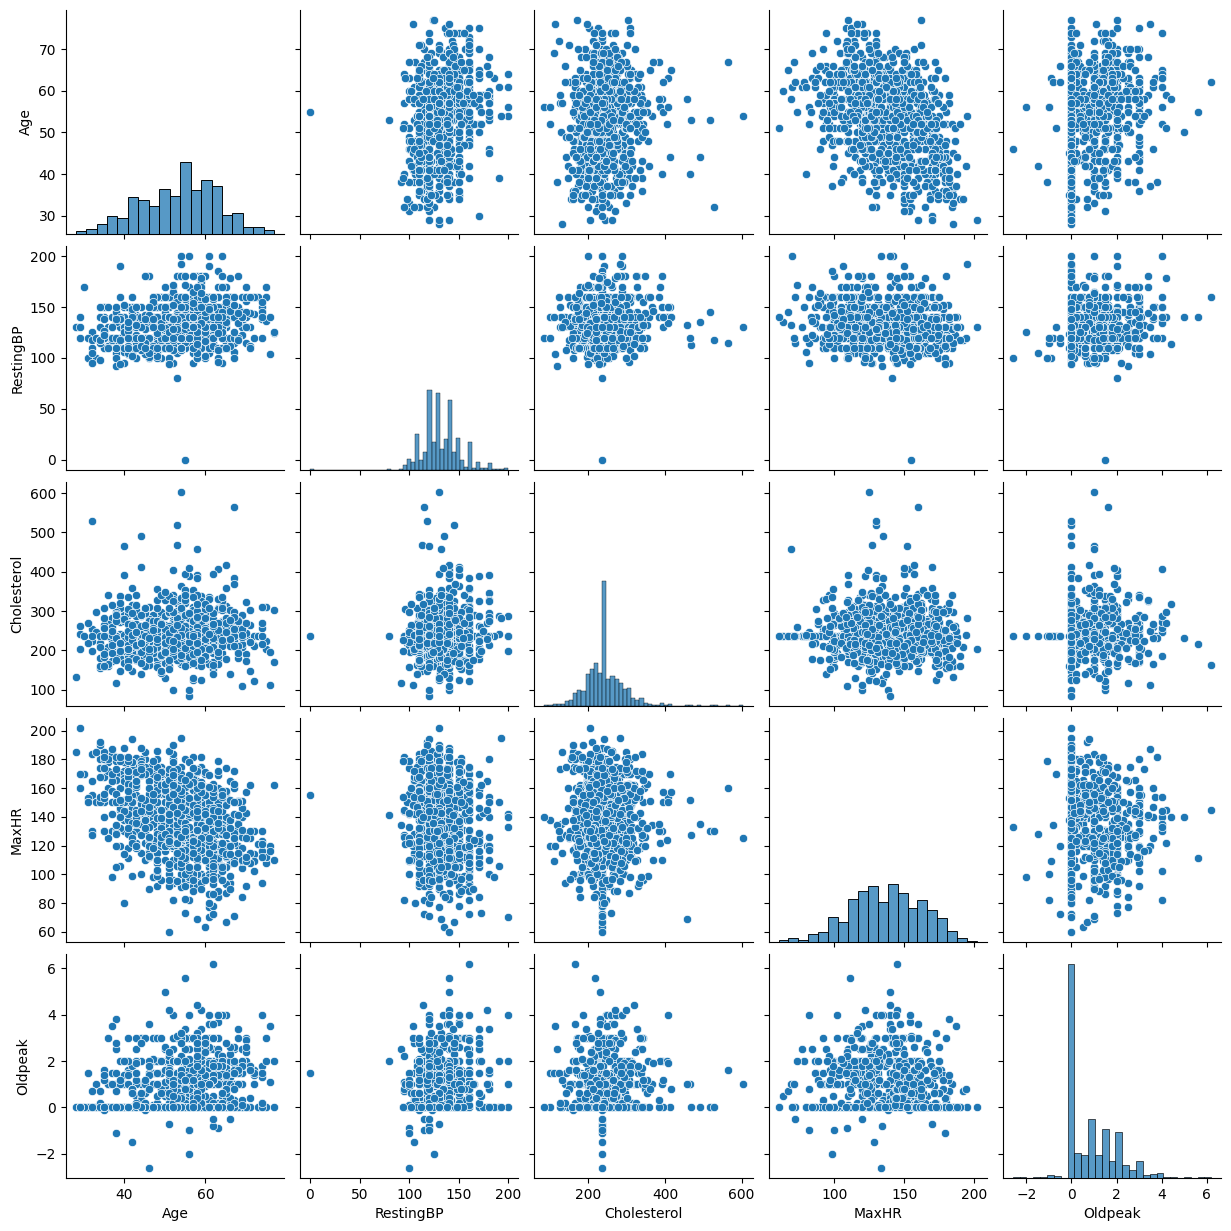

In [16]:
sns.pairplot(df.drop(columns=['FastingBS','HeartDisease']))
plt.show()

### Są to wykresy korelacji cech każda z każdą kolumną numeryczną. Histogramy są w przypadku korelacji samej do siebie

In [90]:
# Liczba kategorii

categorical_cols = df.select_dtypes(exclude=['int', 'float']).columns

for col in categorical_cols:
    print(df[col].value_counts(), end='\n\n')

Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64



W zbiorze danych jest kilkakrotnie więcej danych dla mężczyzn niż dla kobiet.

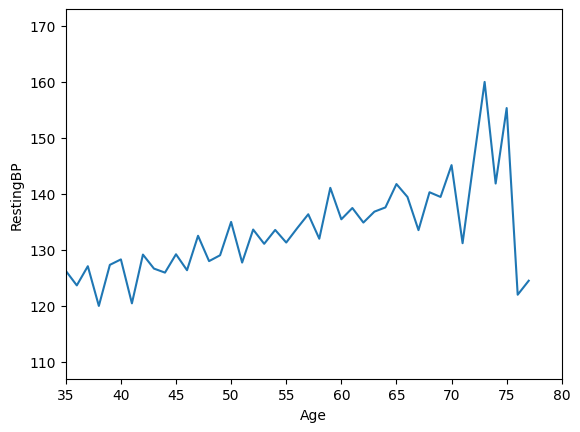

In [126]:
age_bp = df.groupby('Age')['RestingBP'].mean().reset_index()
sns.lineplot(data=age_bp, x='Age', y='RestingBP')
plt.xlim(35, 80)
plt.show()

The x-axis represents age, ranging from 35 to 80 years old.
The y-axis represents resting blood pressure in mmHg, ranging from 110 to 170 mmHg.

There is a general positive correlation, with blood pressure typically increasing with age, though there are fluctuations.
Normal blood pressure for people under 65 years of age is generally considered around 120-129/70-79 mmHg.
A significant drop in recorded blood pressure is visible for ages above 75.

### W raz z wiekiem rośnie ciśnienie krwi w spoczynku

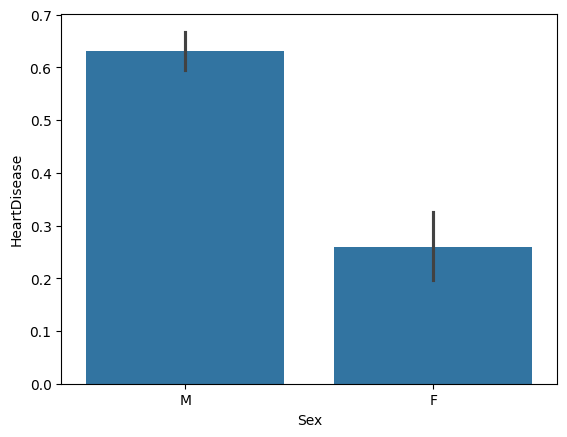

In [20]:
sns.barplot(data=df, x='Sex', y='HeartDisease')
plt.show()

In [114]:
print(df[df['Sex'] == 'M']['HeartDisease'].mean())
print(df[df['Sex'] == 'F']['HeartDisease'].mean())

0.6317241379310344
0.25906735751295334


Dla mężczyzn ('M') średnia to 0.632, co oznacza, że około 63% mężczyzn w tym zbiorze danych ma chorobę serca.

Dla kobiet ('F') średnia to 0.259, czyli około 26% kobiet ma chorobę serca.

Wygląda na to, że mężczyźni w tym zbiorze mają znacznie wyższe ryzyko choroby serca niż kobiety.

To jest analiza opisowa, więc daje jedynie informację o zależności między płcią a chorobą serca w tym konkretnym zbiorze danych. Nie możemy jeszcze mówić o przyczynowości.

/tmp/ipykernel_1926/2742430730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.countplot(x='ChestPainType', data=df, palette='Paired')


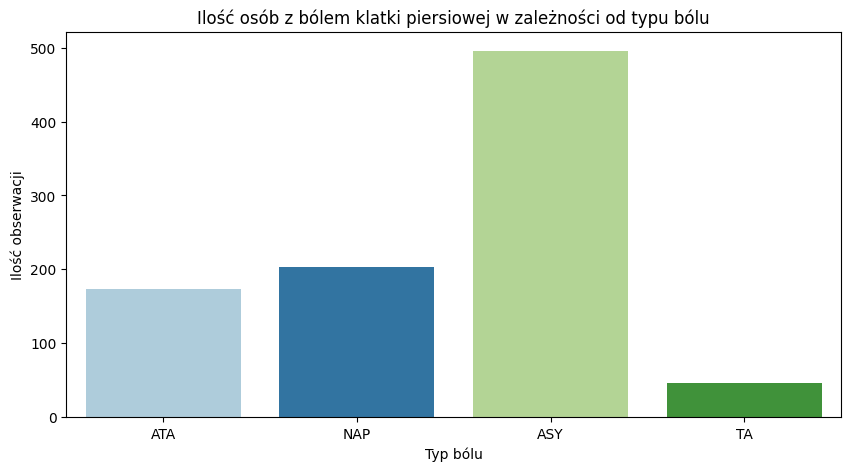

In [21]:
fig, axes = plt.subplots(figsize=(10,5))
g = sns.countplot(x='ChestPainType', data=df, palette='Paired')
g.set_title('Ilość osób z bólem klatki piersiowej w zależności od typu bólu')
g.set_xlabel('Typ bólu')
g.set_ylabel('Ilość obserwacji')

plt.show()


 #### TA: typowa dławica piersiowa, ATA: atypowa dławica piersiowa, NAP: ból niebędący dławicą piersiową, ASY: bezobjawowy

#### Zdecydowana większość bóli pacjentów jest bezobjawowa

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fe1e8241-4925-4ae8-afc5-cf7b713a5643' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>